# Smoking Detection YOLOv8 Training
This notebook is organized into separate cells for dataset discovery, configuration, training, validation, plotting, inference, and summary reporting.

In [1]:
# ============================================
# 0. IMPORTS AND SETUP
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')

# Install ultralytics if not already present
!pip install -q ultralytics

from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# ============================================
# 1. FIND THE DATASET PATH
# ============================================
possible_paths = [
    "/kaggle/input/datasets/roronazoromani/smoking-finalised2-dataset",
    "Smoking.v3i.yolov8",
]

data_yaml = None
base_path = None
for p in possible_paths:
    test_yaml = Path(p) / "data.yaml"
    if test_yaml.exists():
        data_yaml = str(test_yaml)
        base_path = str(Path(p))
        print(f"✅ Dataset found at: {base_path}")
        break

if data_yaml is None:
    print("Searching inside /kaggle/input...")
    for root, dirs, files in os.walk("/kaggle/input"):
        if "data.yaml" in files:
            data_yaml = os.path.join(root, "data.yaml")
            base_path = os.path.dirname(data_yaml)
            print(f"✅ Found at: {base_path}")
            break

if data_yaml is None:
    raise FileNotFoundError("Could not find data.yaml. Make sure your dataset is uploaded correctly.")

with open(data_yaml, 'r') as f:
    print("\n📄 data.yaml content:")
    print(f.read())

Searching inside /kaggle/input...
✅ Found at: /kaggle/input/datasets/roronazoromani/smoking-final-dataset/Smoking.v3i.yolov8

📄 data.yaml content:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['smoking']


roboflow:
  workspace: my-projects-y8vhj
  project: smoking-esifx
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/my-projects-y8vhj/smoking-esifx/dataset/3


In [3]:
# ============================================
# 2. CONFIGURATION
# ============================================
CONFIG = {
    'data_yaml': data_yaml,
    'epochs': 100,
    'imgsz': 640,
    'batch': 16,
    'model_name': 'yolov8n',
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'patience': 15,
    'save_period': 10,
    'project': 'smoking_detection_kaggle',
    'name': 'exp1',
    'pretrained': True,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'weight_decay': 0.0005,
}

print("\n" + "="*60)
print("SMOKING DETECTION - YOLOv8 TRAINING PIPELINE")
print("="*60)
print(f"Device: {CONFIG['device']}")
print(f"Model: {CONFIG['model_name']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Data YAML: {CONFIG['data_yaml']}")


SMOKING DETECTION - YOLOv8 TRAINING PIPELINE
Device: 0
Model: yolov8n
Epochs: 100
Data YAML: /kaggle/input/datasets/roronazoromani/smoking-final-dataset/Smoking.v3i.yolov8/data.yaml


In [4]:
# ============================================
# 3. TRAIN THE MODEL
# ============================================
print("\n🚀 Starting model training...")
model = YOLO(f"{CONFIG['model_name']}.pt") if CONFIG['pretrained'] else YOLO()

results = model.train(
    data=CONFIG['data_yaml'],
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch'],
    device=CONFIG['device'],
    patience=CONFIG['patience'],
    save_period=CONFIG['save_period'],
    project=CONFIG['project'],
    name=CONFIG['name'],
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    weight_decay=CONFIG['weight_decay'],
    augment=True,
    seed=42,
    verbose=True,
)

print("\n✅ Training complete!")


🚀 Starting model training...
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/roronazoromani/smoking-final-dataset/Smoking.v3i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, n

In [5]:
# ============================================
# 4. VALIDATION
# ============================================
best_model_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/weights/best.pt")
if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    val_results = best_model.val(data=CONFIG['data_yaml'])
    
    print("\n📈 Standard Validation Metrics:")
    print(f"   mAP50: {val_results.box.map50:.4f}")
    print(f"   mAP50-95: {val_results.box.map:.4f}")
    print(f"   Precision: {val_results.box.mp:.4f}")
    print(f"   Recall: {val_results.box.mr:.4f}")
else:
    print("⚠️ best.pt not found. Skipping validation.")

⚠️ best.pt not found. Skipping validation.


In [6]:
# ============================================
# 5. EXTRACT TRAINING HISTORY
# ============================================
results_csv = Path(f"{CONFIG['project']}/{CONFIG['name']}/results.csv")
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    rename_map = {}
    for col in df.columns:
        if 'epoch' in col.lower():
            rename_map[col] = 'epoch'
        elif 'train/box_loss' in col:
            rename_map[col] = 'train_box_loss'
        elif 'train/cls_loss' in col:
            rename_map[col] = 'train_cls_loss'
        elif 'metrics/precision' in col:
            rename_map[col] = 'precision'
        elif 'metrics/recall' in col:
            rename_map[col] = 'recall'
        elif 'metrics/mAP50(B)' in col or 'metrics/mAP50' in col:
            rename_map[col] = 'mAP50'
        elif 'metrics/mAP50-95(B)' in col or 'metrics/mAP50-95' in col:
            rename_map[col] = 'mAP50_95'
        elif 'val/box_loss' in col:
            rename_map[col] = 'val_box_loss'
        elif 'val/cls_loss' in col:
            rename_map[col] = 'val_cls_loss'
        elif 'lr/pg0' in col:
            rename_map[col] = 'learning_rate'

    df = df.rename(columns=rename_map)

    if 'mAP50' in df.columns:
        best_idx = df['mAP50'].idxmax()
        best_epoch = df.loc[best_idx, 'epoch']
        best_map50 = df.loc[best_idx, 'mAP50']
        print(f"\n🏆 Best Model: Epoch {int(best_epoch)} with mAP50 = {best_map50:.4f}")
    else:
        best_epoch = None
        best_map50 = None
else:
    df = None
    best_epoch = None
    best_map50 = None

In [7]:
# ============================================
# 6. PLOTTING
# ============================================
if df is not None and len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Smoking Detection Training - {CONFIG["model_name"].upper()}', fontsize=14, fontweight='bold')

    ax = axes[0,0]
    if 'train_box_loss' in df.columns:
        ax.plot(df['epoch'], df['train_box_loss'], label='Train Box Loss')
    if 'val_box_loss' in df.columns:
        ax.plot(df['epoch'], df['val_box_loss'], label='Val Box Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Box Loss')
    ax.set_title('Box Regression Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0,1]
    if 'train_cls_loss' in df.columns:
        ax.plot(df['epoch'], df['train_cls_loss'], label='Train Cls Loss')
    if 'val_cls_loss' in df.columns:
        ax.plot(df['epoch'], df['val_cls_loss'], label='Val Cls Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cls Loss')
    ax.set_title('Classification Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1,0]
    if 'precision' in df.columns:
        ax.plot(df['epoch'], df['precision'], label='Precision', color='green')
    if 'recall' in df.columns:
        ax.plot(df['epoch'], df['recall'], label='Recall', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1,1]
    if 'mAP50' in df.columns:
        ax.plot(df['epoch'], df['mAP50'], label='mAP50', color='blue')
    if 'mAP50_95' in df.columns:
        ax.plot(df['epoch'], df['mAP50_95'], label='mAP50-95', color='red')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mAP')
    ax.set_title('Mean Average Precision')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if best_epoch is not None:
        ax.axvline(x=best_epoch, color='purple', linestyle='--', alpha=0.7, label=f'Best Epoch ({int(best_epoch)})')
        ax.legend()

    plt.tight_layout()
    plt.show()

    if 'learning_rate' in df.columns:
        plt.figure(figsize=(10,5))
        plt.plot(df['epoch'], df['learning_rate'], color='purple')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Schedule')
        plt.grid(True, alpha=0.3)
        plt.show()

    cm_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/confusion_matrix_normalized.png")
    if cm_path.exists():
        from PIL import Image
        plt.figure(figsize=(8,8))
        plt.imshow(Image.open(cm_path))
        plt.title('Normalized Confusion Matrix')
        plt.axis('off')
        plt.show()

    pr_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/PR_curve.png")
    if pr_path.exists():
        plt.figure(figsize=(8,6))
        plt.imshow(Image.open(pr_path))
        plt.title('Precision-Recall Curve')
        plt.axis('off')
        plt.show()

    f1_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/F1_curve.png")
    if f1_path.exists():
        plt.figure(figsize=(8,6))
        plt.imshow(Image.open(f1_path))
        plt.title('F1 vs Confidence Threshold')
        plt.axis('off')
        plt.show()

In [8]:
# ============================================
# 7. INFERENCE ON TEST IMAGES
# ============================================
test_images_dir = Path(base_path) / "test" / "images"
if test_images_dir.exists() and best_model_path.exists():
    print("\n🔍 Running inference on test images...")
    test_model = YOLO(str(best_model_path))
    
    test_images = list(test_images_dir.glob("*.*"))[:6]
    if test_images:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, img_path in enumerate(test_images):
            results = test_model(str(img_path), conf=0.25)
            img_with_boxes = results[0].plot()
            axes[i].imshow(img_with_boxes)
            axes[i].set_title(img_path.name, fontsize=8)
            axes[i].axis('off')

        plt.suptitle("Smoking Detection on Test Images", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

In [9]:
# ============================================
# 8. SUMMARY REPORT
# ============================================
print("\n" + "="*60)
print("TRAINING SUMMARY REPORT")
print("="*60)
if best_epoch is not None:
    print(f"🏆 Best mAP50: {best_map50:.4f} at epoch {int(best_epoch)}")
if df is not None and len(df) > 0:
    last_row = df.iloc[-1]
    print(f"\n📊 Final Epoch Metrics:")
    print(f"   Precision: {last_row.get('precision', 'N/A'):.4f}" if 'precision' in last_row else "   Precision: N/A")
    print(f"   Recall: {last_row.get('recall', 'N/A'):.4f}" if 'recall' in last_row else "   Recall: N/A")
    print(f"   mAP50: {last_row.get('mAP50', 'N/A'):.4f}" if 'mAP50' in last_row else "   mAP50: N/A")
    print(f"   mAP50-95: {last_row.get('mAP50_95', 'N/A'):.4f}" if 'mAP50_95' in last_row else "   mAP50-95: N/A")

print("\n✅ Training pipeline completed successfully!")
print(f"📁 Output directory: {CONFIG['project']}/{CONFIG['name']}/")
print(f"🎯 Best model: {best_model_path}")


TRAINING SUMMARY REPORT

✅ Training pipeline completed successfully!
📁 Output directory: smoking_detection_kaggle/exp1/
🎯 Best model: smoking_detection_kaggle/exp1/weights/best.pt


Found results.csv at: runs/detect/smoking_detection_kaggle/exp1/results.csv


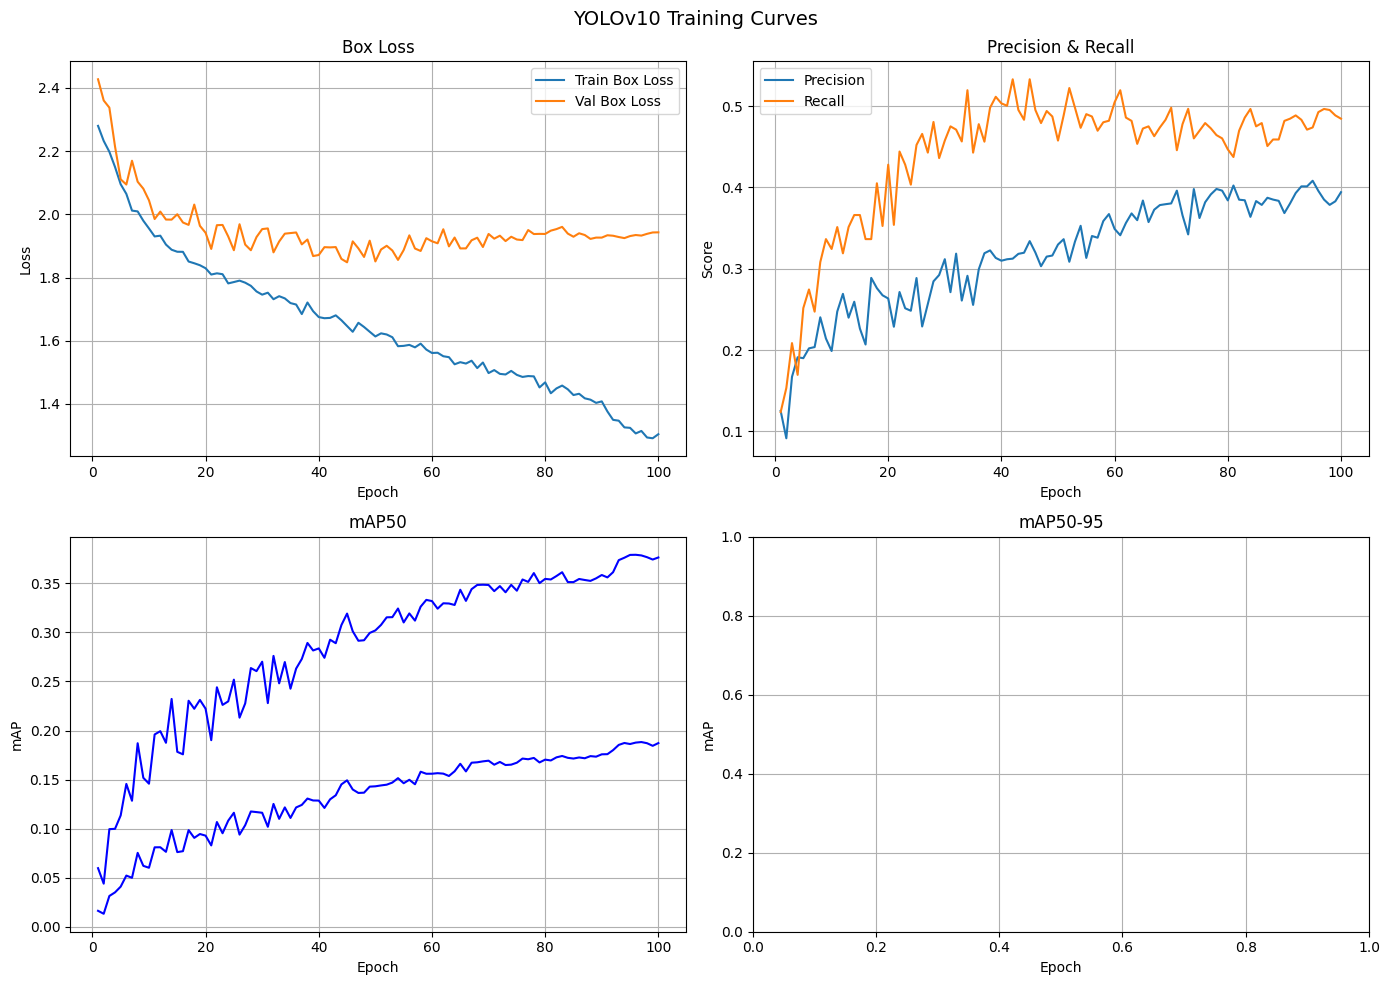

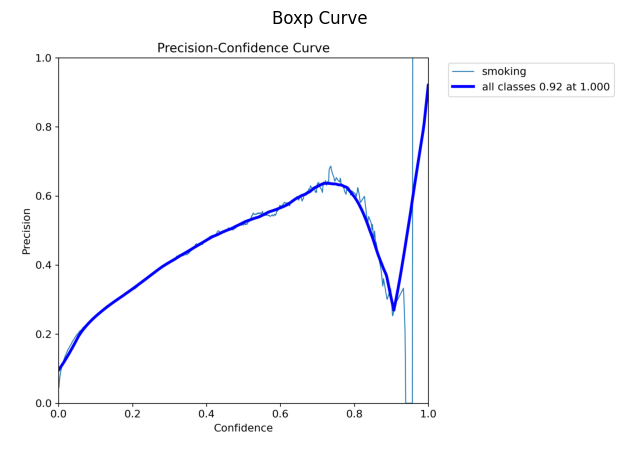

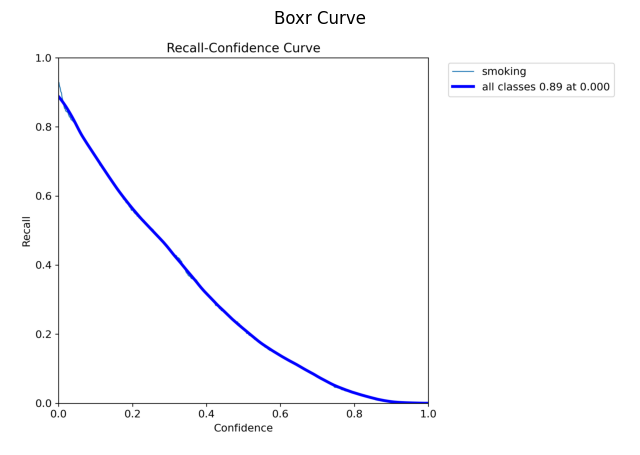

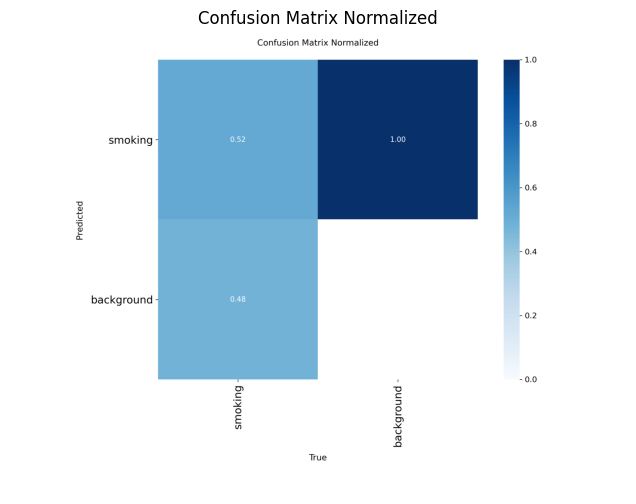

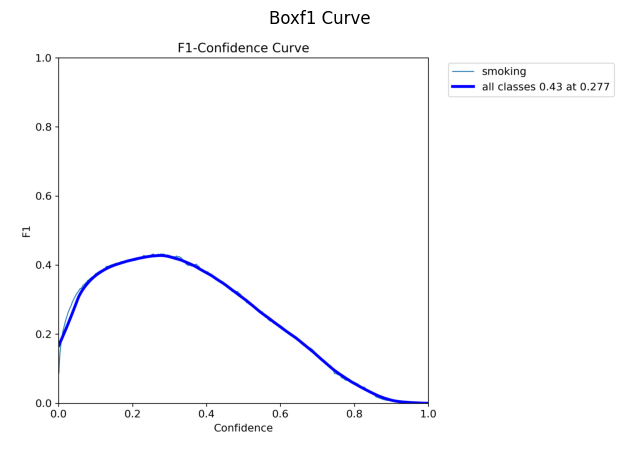

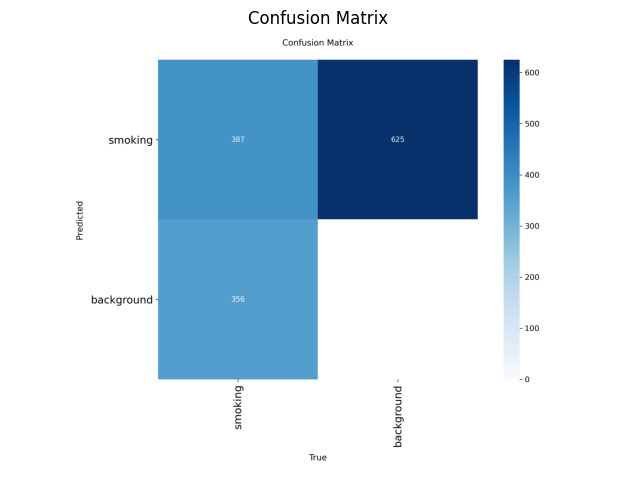

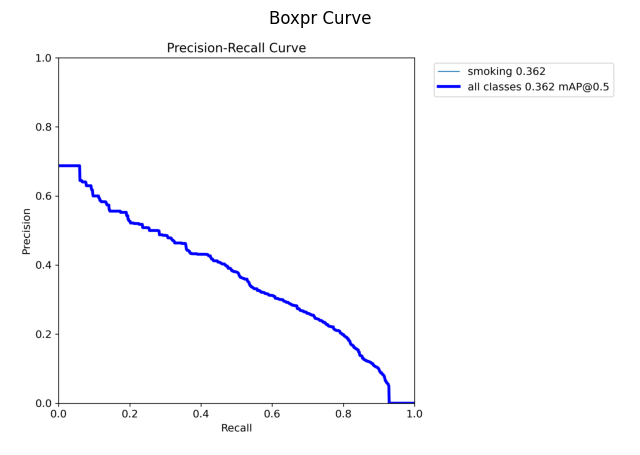

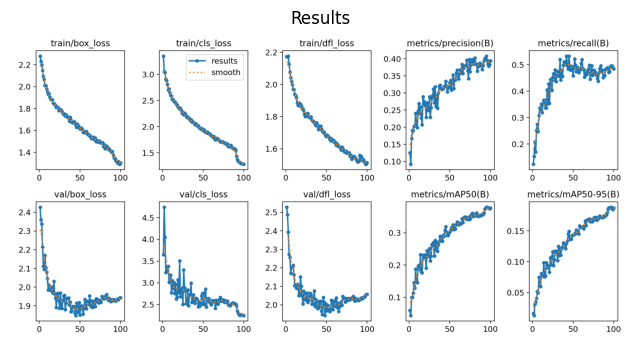

In [10]:
# ============================================
# FORCE DISPLAY OF TRAINING GRAPHS IN KAGGLE
# Run this after training completes
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Enable inline plotting for Kaggle
%matplotlib inline

# Path to your training results.csv
# Adjust if you used a different project/name
results_csv = Path("smoking_detection_yolov10/exp1/results.csv")

if not results_csv.exists():
    # Try to auto-detect
    possible_paths = list(Path(".").glob("**/results.csv"))
    if possible_paths:
        results_csv = possible_paths[0]
        print(f"Found results.csv at: {results_csv}")
    else:
        raise FileNotFoundError("No results.csv found. Did training complete successfully?")

# Load data
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Rename columns for readability
rename_map = {}
for col in df.columns:
    if 'epoch' in col.lower():
        rename_map[col] = 'epoch'
    elif 'train/box_loss' in col:
        rename_map[col] = 'train_box_loss'
    elif 'val/box_loss' in col:
        rename_map[col] = 'val_box_loss'
    elif 'metrics/precision' in col:
        rename_map[col] = 'precision'
    elif 'metrics/recall' in col:
        rename_map[col] = 'recall'
    elif 'metrics/mAP50' in col:
        rename_map[col] = 'mAP50'
    elif 'metrics/mAP50-95' in col:
        rename_map[col] = 'mAP50_95'
df = df.rename(columns=rename_map)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("YOLOv10 Training Curves", fontsize=14)

# Box Loss
ax = axes[0,0]
if 'train_box_loss' in df:
    ax.plot(df['epoch'], df['train_box_loss'], label='Train Box Loss')
if 'val_box_loss' in df:
    ax.plot(df['epoch'], df['val_box_loss'], label='Val Box Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Box Loss')
ax.legend()
ax.grid(True)

# Precision & Recall
ax = axes[0,1]
if 'precision' in df:
    ax.plot(df['epoch'], df['precision'], label='Precision')
if 'recall' in df:
    ax.plot(df['epoch'], df['recall'], label='Recall')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall')
ax.legend()
ax.grid(True)

# mAP50
ax = axes[1,0]
if 'mAP50' in df:
    ax.plot(df['epoch'], df['mAP50'], label='mAP50', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('mAP50')
ax.grid(True)

# mAP50-95
ax = axes[1,1]
if 'mAP50_95' in df:
    ax.plot(df['epoch'], df['mAP50_95'], label='mAP50-95', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('mAP50-95')
ax.grid(True)

plt.tight_layout()
plt.show()  # This forces display in Kaggle

# Also display any saved PNG plots (confusion matrix, PR curve, etc.)
saved_plots_dir = results_csv.parent
for plot_file in saved_plots_dir.glob("*.png"):
    if "chart" not in plot_file.name:  # avoid results_chart.png
        from PIL import Image
        img = Image.open(plot_file)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(plot_file.stem.replace('_', ' ').title())
        plt.axis('off')
        plt.show()